In [368]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/salary-dataset-simple-linear-regression/Salary_dataset.csv


In [369]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abhishek14398/salary-dataset-simple-linear-regression")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/salary-dataset-simple-linear-regression


In [370]:
df=pd.read_csv('/kaggle/input/salary-dataset-simple-linear-regression/Salary_dataset.csv')

In [371]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [372]:
df.columns

Index(['Unnamed: 0', 'YearsExperience', 'Salary'], dtype='object')

In [373]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [374]:
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [375]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [376]:
df.duplicated().sum()

0

In [377]:
X=df.iloc[:,0]
Y=df.iloc[:,1]

In [378]:
Y

0      39344.0
1      46206.0
2      37732.0
3      43526.0
4      39892.0
5      56643.0
6      60151.0
7      54446.0
8      64446.0
9      57190.0
10     63219.0
11     55795.0
12     56958.0
13     57082.0
14     61112.0
15     67939.0
16     66030.0
17     83089.0
18     81364.0
19     93941.0
20     91739.0
21     98274.0
22    101303.0
23    113813.0
24    109432.0
25    105583.0
26    116970.0
27    112636.0
28    122392.0
29    121873.0
Name: Salary, dtype: float64

In [379]:
from sklearn.model_selection import train_test_split

In [380]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,random_state=42,test_size=0.2)

In [381]:
from sklearn.preprocessing import StandardScaler

In [382]:
from sklearn.linear_model import LinearRegression
le=LinearRegression()
le.fit((x_train.values.reshape(-1, 1)), y_train)  # إذا كان x_train من Pandas,y_train)
y_pred=le.predict((x_test.values.reshape(-1, 1)))  # إذا كان x_train من Pandas)

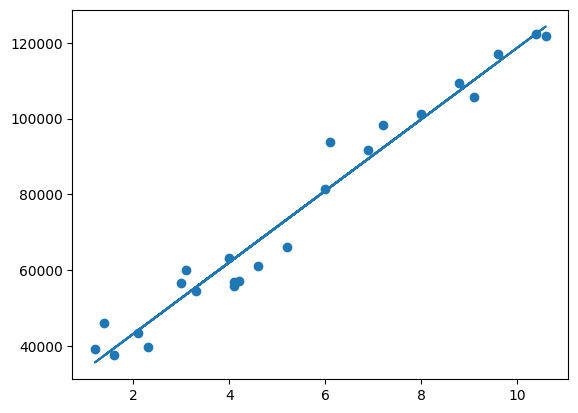

In [383]:
import matplotlib.pyplot as plt
plt.scatter(x_train.values.reshape(-1,1),y_train)
plt.plot(x_train.values.reshape(-1,1),le.predict(x_train.values.reshape(-1,1)))

In [384]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Mean Squared Error: ", mse)
print("Mean Absolute Error: ", mae)
print("Root Mean Squared Error: ", rmse)

Mean Squared Error:  49830096.855908394
Mean Absolute Error:  6286.453830757745
Root Mean Squared Error:  7059.04362190151


In [385]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
print("R2 Score: ",score)

R2 Score:  0.9024461774180497


In [386]:
residuals = y_test - y_pred
residuals

27    -3155.210113
15    -3560.278095
23    11215.131339
17     7820.195776
8      8967.207955
9     -3000.699707
Name: Salary, dtype: float64